# 12B_model_training_xgboost_risk.ipynb — XGBoost para clasificación directa de riesgo marítimo

Este notebook entrena modelos **XGBClassifier** para predecir directamente el nivel de riesgo marítimo futuro:

```text
target_risk_3h
target_risk_6h
target_risk_12h
target_risk_24h
```

Objetivo metodológico:

```text
Comparar dos enfoques:
A) LightGBMRegressor → predice hs futura → riesgo derivado por umbrales
B) XGBClassifier     → predice directamente el nivel de riesgo
```

Entrada:

```text
gold/training_dataset/
```

Salidas:

```text
models/xgboost_risk/
gold/model_results/xgboost_risk/
```

Métricas clave:

```text
accuracy
balanced_accuracy
macro_f1
weighted_f1
recall clase 2
recall clase 3
```

## Celda 0 — Montar Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Celda 1 — Instalar librerías

In [3]:
!pip -q install xgboost scikit-learn pyarrow joblib matplotlib tqdm

## Celda 2 — Imports, rutas y configuración

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
import joblib
import json
import shutil
import gc
import warnings
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    log_loss,
)

from xgboost import XGBClassifier
import xgboost as xgb

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
GOLD_DIR = BASE_DIR / "gold"
GOLD_TRAINING_DIR = GOLD_DIR / "training_dataset"

MODELS_DIR = BASE_DIR / "models" / "xgboost_risk"
RESULTS_DIR = GOLD_DIR / "model_results" / "xgboost_risk"
META_DIR = GOLD_DIR / "_metadata"

for d in [MODELS_DIR, RESULTS_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS = [3, 6, 12, 24]
TARGET_RISK_COLS = [f"target_risk_{h}h" for h in HORIZONS_HOURS]

USE_COMMON_ZONES_ONLY = True
USE_ZONA_ID_AS_FEATURE = False

# Dejar None para entrenamiento completo. Útil reducir si Colab se queda corto.
MAX_TRAIN_ROWS_PER_HORIZON = None
MAX_VAL_ROWS_PER_HORIZON = None
MAX_TEST_ROWS_PER_HORIZON = None

RANDOM_STATE = 42
MAX_MISSING_PCT_FEATURE = 98.0

# Balanceo adicional: queremos penalizar más fallar riesgo alto/extremo.
CLASS_SAFETY_BOOST = {0: 1.00, 1: 1.00, 2: 1.25, 3: 1.75}

print("Versión xgboost:", xgb.__version__)
print("GOLD_TRAINING_DIR:", GOLD_TRAINING_DIR)
print("Existe:", GOLD_TRAINING_DIR.exists())

if not GOLD_TRAINING_DIR.exists():
    raise FileNotFoundError("No existe gold/training_dataset/. Ejecuta primero 11_gold_training_dataset.ipynb.")

Versión xgboost: 3.2.0
GOLD_TRAINING_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/training_dataset
Existe: True


## Celda 3 — Funciones auxiliares robustas

In [5]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def sample_rows(df, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state).sort_index()


def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def classification_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="Int64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="Int64")
    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        out = {"n": 0, "accuracy": np.nan, "balanced_accuracy": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan}
        for cls in [0, 1, 2, 3]:
            out[f"precision_class_{cls}"] = np.nan
            out[f"recall_class_{cls}"] = np.nan
            out[f"f1_class_{cls}"] = np.nan
            out[f"support_class_{cls}"] = 0
        return out

    yt = y_true[mask].astype(int).values
    yp = y_pred[mask].astype(int).values
    labels = [0, 1, 2, 3]

    precision, recall, f1, support = precision_recall_fscore_support(
        yt, yp, labels=labels, zero_division=0
    )

    out = {
        "n": int(mask.sum()),
        "accuracy": float(accuracy_score(yt, yp)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, labels=labels, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, labels=labels, average="weighted", zero_division=0)),
    }

    for i, cls in enumerate(labels):
        out[f"precision_class_{cls}"] = float(precision[i])
        out[f"recall_class_{cls}"] = float(recall[i])
        out[f"f1_class_{cls}"] = float(f1[i])
        out[f"support_class_{cls}"] = int(support[i])

    return out


def compute_balanced_sample_weights(y):
    y = pd.Series(np.asarray(y), dtype="int64")
    counts = y.value_counts().to_dict()
    n = len(y)
    n_classes = 4

    base_weights = {}
    for cls in [0, 1, 2, 3]:
        count = counts.get(cls, 0)
        base_weights[cls] = n / (n_classes * count) if count > 0 else 0.0

    final_weights = {
        cls: base_weights.get(cls, 0.0) * CLASS_SAFETY_BOOST.get(cls, 1.0)
        for cls in [0, 1, 2, 3]
    }
    weights = y.map(final_weights).astype("float32").values
    return weights, final_weights


def safe_predict_proba(model, X):
    proba = np.asarray(model.predict_proba(X))
    if proba.shape[1] == 4:
        return proba

    fixed = np.zeros((proba.shape[0], 4), dtype="float32")
    classes = list(model.classes_)
    for i, cls in enumerate(classes):
        if int(cls) in [0, 1, 2, 3]:
            fixed[:, int(cls)] = proba[:, i]
    return fixed


def proba_to_pred_class(proba):
    return np.argmax(np.asarray(proba), axis=1).astype("int64")


def persistence_risk_baseline(df):
    hs = pd.to_numeric(df["simar_hs"], errors="coerce")
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    out.loc[hs < 1.0] = 0
    out.loc[(hs >= 1.0) & (hs < 2.0)] = 1
    out.loc[(hs >= 2.0) & (hs < 3.0)] = 2
    out.loc[hs >= 3.0] = 3
    return out.astype("Int64").values


def plot_confusion_matrix(cm, title, out_path):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.xticks([0, 1, 2, 3])
    plt.yticks([0, 1, 2, 3])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

## Celda 4 — Cargar Gold training dataset

In [6]:
dataset = ds.dataset(str(GOLD_TRAINING_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])
gold["split"] = gold["split"].astype(str)

print("Gold cargado:")
memory_report("gold", gold)
print("Splits:")
display(gold["split"].value_counts(dropna=False).reset_index())
print("Rango temporal:", gold["timestamp"].min(), "→", gold["timestamp"].max())
print("Zonas:", gold["zona_id"].nunique())
display(gold.head())

Gold cargado:
gold: shape=(983328, 142), memoria≈1552.1 MB
Splits:


,split,count
0,train,698712
1,test,197256
2,val,87360


Rango temporal: 2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Zonas: 14


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,target_risk_24h,gold_dataset_version,target_source,risk_threshold_low_max,risk_threshold_moderate_max,risk_threshold_high_max,has_any_target,is_trainable_target_3h,split,year
0,2024-01-01 00:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.49,129,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
1,2024-01-01 01:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.57,270,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
2,2024-01-01 02:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.63,283,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
3,2024-01-01 03:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.15,NaN,14.66,2.53,303,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
4,2024-01-01 04:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.17,NaN,16.12,2.30,32,0.08,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024


## Celda 5 — Filtrar zonas comunes train/val/test

In [7]:
if USE_COMMON_ZONES_ONLY:
    zones_by_split = {
        split: set(gold.loc[gold["split"] == split, "zona_id"].dropna().astype(str).unique())
        for split in ["train", "val", "test"]
    }
    common_zones = set.intersection(*zones_by_split.values())

    print("Zonas train:", len(zones_by_split["train"]))
    print("Zonas val:", len(zones_by_split["val"]))
    print("Zonas test:", len(zones_by_split["test"]))
    print("Zonas comunes:", len(common_zones))

    if len(common_zones) == 0:
        raise ValueError("No hay zonas comunes entre train/val/test.")

    before = len(gold)
    gold = gold[gold["zona_id"].astype(str).isin(common_zones)].copy()
    after = len(gold)
    print(f"Filtrado a zonas comunes: {before:,} → {after:,} filas")
else:
    common_zones = set(gold["zona_id"].dropna().astype(str).unique())
    print("Se usan todas las zonas:", len(common_zones))

split_zone_summary = (
    gold.groupby("split", as_index=False)
    .agg(rows=("zona_id", "size"), zones=("zona_id", "nunique"), timestamp_min=("timestamp", "min"), timestamp_max=("timestamp", "max"))
)
display(split_zone_summary)
split_zone_summary.to_csv(RESULTS_DIR / "split_zone_summary.csv", index=False)

Zonas train: 10
Zonas val: 10
Zonas test: 14
Zonas comunes: 10
Filtrado a zonas comunes: 983,328 → 960,384 filas


,split,rows,zones,timestamp_min,timestamp_max
0,test,174312,10,2024-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00
1,train,698712,10,2015-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00
2,val,87360,10,2023-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00


## Celda 6 — Selección automática de features

In [8]:
hard_exclude = set([
    "timestamp", "date", "split", "gold_dataset_version", "target_source",
    "has_any_target", "is_trainable_target_3h", "risk_threshold_low_max",
    "risk_threshold_moderate_max", "risk_threshold_high_max", "nombre_zona", "municipio",
])

if not USE_ZONA_ID_AS_FEATURE:
    hard_exclude.add("zona_id")

for c in gold.columns:
    if c.startswith("target_"):
        hard_exclude.add(c)

for c in ["simar_ocean_lat", "simar_ocean_lon"]:
    if c in gold.columns:
        hard_exclude.add(c)

categorical_candidates = [
    "zona_id" if USE_ZONA_ID_AS_FEATURE else None,
    "isla", "tipo_zona", "orientacion_costa", "vulnerabilidad_costera", "redmar_tide_phase",
]
categorical_candidates = [c for c in categorical_candidates if c is not None and c in gold.columns]

rows = []
for c in gold.columns:
    missing_pct = float(gold[c].isna().mean() * 100)
    nunique = int(gold[c].nunique(dropna=True))
    use = True
    reason = ""

    if c in hard_exclude:
        use = False; reason = "hard_exclude"
    elif missing_pct >= MAX_MISSING_PCT_FEATURE:
        use = False; reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
    elif nunique <= 1:
        use = False; reason = "constant_or_all_missing"
    elif str(gold[c].dtype).startswith("datetime"):
        use = False; reason = "datetime"

    rows.append({
        "column": c, "dtype": str(gold[c].dtype), "missing_pct": missing_pct,
        "nunique": nunique, "selected_feature": use, "reason_excluded": reason,
        "is_categorical_raw": c in categorical_candidates,
    })

feature_audit = pd.DataFrame(rows)
feature_cols = feature_audit.loc[feature_audit["selected_feature"], "column"].tolist()
categorical_features = [c for c in categorical_candidates if c in feature_cols]
numeric_features = [c for c in feature_cols if c not in categorical_features]

print("Features seleccionadas:", len(feature_cols))
print("Numéricas:", len(numeric_features))
print("Categóricas a codificar:", categorical_features)

display(feature_audit.sort_values(["selected_feature", "missing_pct"], ascending=[True, False]).head(60))
display(feature_audit[feature_audit["selected_feature"]].head(100))

feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit.csv", index=False)
save_json({
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "use_common_zones_only": USE_COMMON_ZONES_ONLY,
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
    "horizons_hours": HORIZONS_HOURS,
    "class_safety_boost": CLASS_SAFETY_BOOST,
}, RESULTS_DIR / "selected_features.json")

Features seleccionadas: 109
Numéricas: 106
Categóricas a codificar: ['isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected_feature,reason_excluded,is_categorical_raw
5,simar_hmax,float64,100.000000,0,False,missing_pct_ge_98.0,False
13,simar_wind_wave_period,float64,100.000000,0,False,missing_pct_ge_98.0,False
14,simar_stokes_drift,float64,100.000000,0,False,missing_pct_ge_98.0,False
32,simar_wind_gust,float64,100.000000,0,False,missing_pct_ge_98.0,False
33,simar_temperature_air,float64,100.000000,0,False,missing_pct_ge_98.0,False
34,simar_pressure,float64,100.000000,0,False,missing_pct_ge_98.0,False
35,simar_precipitation,float64,100.000000,0,False,missing_pct_ge_98.0,False
36,simar_humidity,float64,100.000000,0,False,missing_pct_ge_98.0,False
128,target_hs_24h,float64,0.368603,705,False,hard_exclude,False
132,target_risk_24h,Int64,0.368603,4,False,hard_exclude,False


,column,dtype,missing_pct,nunique,selected_feature,reason_excluded,is_categorical_raw
4,simar_hs,float64,0.000000,705,True,,False
6,simar_tp,float64,0.000000,1813,True,,False
7,simar_tm02,float64,0.000000,1329,True,,False
8,simar_wave_direction,int64,0.000000,360,True,,False
9,simar_swell_height,float64,0.000000,604,True,,False
...,...,...,...,...,...,...,...
112,simar_hs_lag_24h,float64,0.368603,705,True,,False
113,simar_tp_lag_24h,float64,0.368603,1813,True,,False
114,simar_wave_direction_lag_24h,float64,0.368603,360,True,,False
115,simar_wind_speed_lag_24h,float64,10.330868,1777,True,,False


## Celda 7 — Codificar categóricas y preparar matriz numérica

In [9]:
category_maps = {}

for c in categorical_features:
    train_values = gold.loc[gold["split"] == "train", c].astype("string").fillna("UNKNOWN").unique().tolist()
    train_values = sorted([str(v) for v in train_values])
    mapping = {v: i for i, v in enumerate(train_values)}
    category_maps[c] = mapping

    gold[c + "_encoded"] = (
        gold[c].astype("string").fillna("UNKNOWN").map(mapping).fillna(-1).astype("int32")
    )

feature_cols_encoded = []
for c in feature_cols:
    feature_cols_encoded.append(c + "_encoded" if c in categorical_features else c)

for c in feature_cols_encoded:
    gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

for c in TARGET_RISK_COLS:
    if c in gold.columns:
        gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("Int64")

memory_report("gold preparado XGBoost", gold[feature_cols_encoded + TARGET_RISK_COLS + ["split", "timestamp", "zona_id"]])
display(gold[feature_cols_encoded].head())

save_json(category_maps, RESULTS_DIR / "category_maps.json")
save_json(category_maps, MODELS_DIR / "category_maps.json")

gold preparado XGBoost: shape=(960384, 116), memoria≈558.5 MB


,simar_hs,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,simar_swell_period,simar_swell_direction,simar_wind_wave_height,isla_encoded,zona_lat,...,simar_wind_direction_lag_24h,redmar_sea_level_lag_24h,simar_current_speed_lag_24h,simar_hs_roll_mean_6h,simar_hs_roll_max_12h,simar_hs_roll_mean_24h,simar_wind_speed_roll_mean_6h,simar_wind_speed_roll_max_12h,redmar_sea_level_roll_std_12h,year
0,0.14,14.660000,2.49,129.0,0.06,14.55,246.0,0.00,1.0,28.2113,...,NaN,1.428,0.195,0.145000,0.18,0.182500,NaN,NaN,0.403271,2024.0
1,0.14,14.660000,2.57,270.0,0.06,14.75,246.0,0.00,1.0,28.2113,...,NaN,1.835,0.194,0.143333,0.18,0.179167,NaN,NaN,0.375392,2024.0
2,0.14,14.660000,2.63,283.0,0.07,14.93,245.0,0.00,1.0,28.2113,...,NaN,2.201,0.188,0.141667,0.17,0.176667,NaN,NaN,0.363041,2024.0
3,0.15,14.660000,2.53,303.0,0.07,15.07,245.0,0.00,1.0,28.2113,...,NaN,2.438,0.162,0.140000,0.16,0.174167,NaN,NaN,0.368798,2024.0
4,0.17,16.120001,2.30,32.0,0.08,15.19,245.0,0.02,1.0,28.2113,...,NaN,2.494,0.113,0.141667,0.16,0.172500,NaN,NaN,0.390377,2024.0


## Celda 8 — Función de entrenamiento XGBClassifier por horizonte

In [10]:
def prepare_xy_classification(df, feature_cols, target_col, max_rows=None):
    work = df[df[target_col].notna()].copy()
    work = sample_rows(work, max_rows=max_rows)
    X = work[feature_cols].copy()
    y = work[target_col].astype("int64")
    mask = y.isin([0, 1, 2, 3])
    return X.loc[mask].copy(), y.loc[mask].copy(), work.loc[mask].copy()


def build_xgb_classifier(n_estimators=900):
    return XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=n_estimators,
        learning_rate=0.035,
        max_depth=6,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.05,
        reg_alpha=0.05,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=1,
    )


def fit_xgb_robust(model, X_train, y_train, sample_weight, X_val, y_val):
    # Compatible con varias versiones de xgboost.
    try:
        model.set_params(early_stopping_rounds=60)
        model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], verbose=100)
        return model, "early_stopping_in_params"
    except Exception as e:
        print("AVISO: fit con early stopping no fue compatible o falló:", repr(e))
        print("Reintentando sin early stopping con 500 árboles.")
        model = build_xgb_classifier(n_estimators=500)
        model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], verbose=100)
        return model, "no_early_stopping_fallback"


def train_xgb_for_horizon(horizon):
    target_col = f"target_risk_{horizon}h"
    print("=" * 80)
    print(f"Entrenando XGBClassifier horizonte +{horizon}h")
    print("Target:", target_col)

    train_df = gold[gold["split"] == "train"].copy()
    val_df = gold[gold["split"] == "val"].copy()
    test_df = gold[gold["split"] == "test"].copy()

    X_train, y_train, train_used = prepare_xy_classification(train_df, feature_cols_encoded, target_col, MAX_TRAIN_ROWS_PER_HORIZON)
    X_val, y_val, val_used = prepare_xy_classification(val_df, feature_cols_encoded, target_col, MAX_VAL_ROWS_PER_HORIZON)
    X_test, y_test, test_used = prepare_xy_classification(test_df, feature_cols_encoded, target_col, MAX_TEST_ROWS_PER_HORIZON)

    print("Train:", X_train.shape, y_train.value_counts().sort_index().to_dict())
    print("Val:", X_val.shape, y_val.value_counts().sort_index().to_dict())
    print("Test:", X_test.shape, y_test.value_counts().sort_index().to_dict())

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError(f"Algún split está vacío para {target_col}")
    if y_train.nunique() < 2:
        raise ValueError(f"El target {target_col} tiene menos de 2 clases en train.")

    sample_weight_train, class_weights = compute_balanced_sample_weights(y_train)
    print("Class weights:", class_weights)

    model = build_xgb_classifier()
    model, fit_mode = fit_xgb_robust(model, X_train, y_train, sample_weight_train, X_val, y_val)

    proba_train = safe_predict_proba(model, X_train)
    proba_val = safe_predict_proba(model, X_val)
    proba_test = safe_predict_proba(model, X_test)

    pred_train = proba_to_pred_class(proba_train)
    pred_val = proba_to_pred_class(proba_val)
    pred_test = proba_to_pred_class(proba_test)

    pred_base_train = persistence_risk_baseline(train_used)
    pred_base_val = persistence_risk_baseline(val_used)
    pred_base_test = persistence_risk_baseline(test_used)

    metrics_rows = []
    for split_name, y_true, pred_xgb, pred_base, proba_xgb in [
        ("train", y_train, pred_train, pred_base_train, proba_train),
        ("val", y_val, pred_val, pred_base_val, proba_val),
        ("test", y_test, pred_test, pred_base_test, proba_test),
    ]:
        mx = classification_metrics(y_true, pred_xgb)
        mb = classification_metrics(y_true, pred_base)
        try:
            loss = float(log_loss(y_true, proba_xgb, labels=[0, 1, 2, 3]))
        except Exception:
            loss = np.nan
        metrics_rows.append({"horizon_hours": horizon, "target": target_col, "split": split_name, "model": "XGBClassifier", "log_loss": loss, "fit_mode": fit_mode, **mx})
        metrics_rows.append({"horizon_hours": horizon, "target": target_col, "split": split_name, "model": "PersistenceRisk", "log_loss": np.nan, "fit_mode": "baseline", **mb})

    metrics_df = pd.DataFrame(metrics_rows)

    for split_name, y_true, pred_xgb, pred_base in [
        ("train", y_train, pred_train, pred_base_train),
        ("val", y_val, pred_val, pred_base_val),
        ("test", y_test, pred_test, pred_base_test),
    ]:
        cm_xgb = confusion_matrix(y_true, pred_xgb, labels=[0, 1, 2, 3])
        cm_base = confusion_matrix(y_true, pred_base, labels=[0, 1, 2, 3])
        pd.DataFrame(cm_xgb, index=[f"true_{i}" for i in [0, 1, 2, 3]], columns=[f"pred_{i}" for i in [0, 1, 2, 3]]).to_csv(RESULTS_DIR / f"confusion_matrix_xgb_h{horizon}_{split_name}.csv")
        pd.DataFrame(cm_base, index=[f"true_{i}" for i in [0, 1, 2, 3]], columns=[f"pred_{i}" for i in [0, 1, 2, 3]]).to_csv(RESULTS_DIR / f"confusion_matrix_persistence_h{horizon}_{split_name}.csv")
        if split_name == "test":
            plot_confusion_matrix(cm_xgb, f"XGB riesgo +{horizon}h test", RESULTS_DIR / f"plot_confusion_matrix_xgb_h{horizon}_test.png")

    report = classification_report(y_test, pred_test, labels=[0, 1, 2, 3], output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    report_df["horizon_hours"] = horizon
    report_df.to_csv(RESULTS_DIR / f"classification_report_test_xgb_h{horizon}.csv", index=False)

    pred_val_df = val_used[["zona_id", "timestamp", "split", "isla", "lat", "lon", "simar_hs", target_col]].copy()
    pred_val_df["horizon_hours"] = horizon
    pred_val_df["y_true_risk"] = y_val.values
    pred_val_df["pred_risk_xgb"] = pred_val
    pred_val_df["pred_risk_persistence"] = pred_base_val
    for cls in [0, 1, 2, 3]:
        pred_val_df[f"proba_risk_{cls}"] = proba_val[:, cls]

    pred_test_df = test_used[["zona_id", "timestamp", "split", "isla", "lat", "lon", "simar_hs", target_col]].copy()
    pred_test_df["horizon_hours"] = horizon
    pred_test_df["y_true_risk"] = y_test.values
    pred_test_df["pred_risk_xgb"] = pred_test
    pred_test_df["pred_risk_persistence"] = pred_base_test
    for cls in [0, 1, 2, 3]:
        pred_test_df[f"proba_risk_{cls}"] = proba_test[:, cls]

    predictions_df = pd.concat([pred_val_df, pred_test_df], ignore_index=True)

    booster = model.get_booster()
    score_gain = booster.get_score(importance_type="gain")
    score_weight = booster.get_score(importance_type="weight")
    importance_df = pd.DataFrame([
        {"feature": f, "importance_gain": float(score_gain.get(f, 0.0)), "importance_weight": float(score_weight.get(f, 0.0)), "horizon_hours": horizon}
        for f in feature_cols_encoded
    ]).sort_values("importance_gain", ascending=False)

    model_path = MODELS_DIR / f"xgb_risk_{horizon}h.pkl"
    joblib.dump(model, model_path)
    print("Modelo guardado:", model_path)

    return {
        "horizon": horizon,
        "model": model,
        "metrics": metrics_df,
        "predictions": predictions_df,
        "importance": importance_df,
        "report_test": report_df,
        "model_path": str(model_path),
        "class_weights": class_weights,
        "fit_mode": fit_mode,
    }

## Celda 9 — Entrenar modelos XGBoost por horizonte

Entrenando XGBClassifier horizonte +3h
Target: target_risk_3h
Train: (698181, 109) {0: 122441, 1: 371292, 2: 164473, 3: 39975}
Val: (87300, 109) {0: 14857, 1: 44724, 2: 23518, 3: 4201}
Test: (174135, 109) {0: 25797, 1: 91327, 2: 43696, 3: 13315}
Class weights: {0: 1.4255457730662116, 1: 0.470102372256876, 2: 1.3265494184455806, 3: 7.641130393996247}
[0]	validation_0-mlogloss:1.45328
[100]	validation_0-mlogloss:0.21911
[200]	validation_0-mlogloss:0.17843
[300]	validation_0-mlogloss:0.16932
[400]	validation_0-mlogloss:0.16443
[500]	validation_0-mlogloss:0.16042
[600]	validation_0-mlogloss:0.15709
[700]	validation_0-mlogloss:0.15436
[800]	validation_0-mlogloss:0.15220
[899]	validation_0-mlogloss:0.15040


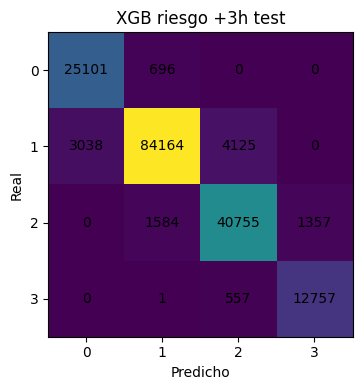

Modelo guardado: /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/xgboost_risk/xgb_risk_3h.pkl
Entrenando XGBClassifier horizonte +6h
Target: target_risk_6h
Train: (697650, 109) {0: 122371, 1: 371009, 2: 164335, 3: 39935}
Val: (87240, 109) {0: 14849, 1: 44665, 2: 23525, 3: 4201}
Test: (173958, 109) {0: 25779, 1: 91245, 2: 43637, 3: 13297}
Class weights: {0: 1.4252764135293492, 1: 0.47010315113649537, 2: 1.3266536343444792, 3: 7.642966695880807}
[0]	validation_0-mlogloss:1.46341
[100]	validation_0-mlogloss:0.37754
[200]	validation_0-mlogloss:0.32706
[300]	validation_0-mlogloss:0.31134
[400]	validation_0-mlogloss:0.30270
[500]	validation_0-mlogloss:0.29570
[600]	validation_0-mlogloss:0.29052
[700]	validation_0-mlogloss:0.28641
[800]	validation_0-mlogloss:0.28263
[899]	validation_0-mlogloss:0.27946


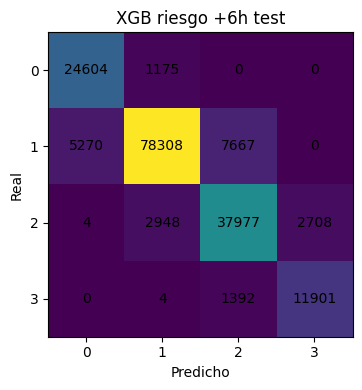

Modelo guardado: /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/xgboost_risk/xgb_risk_6h.pkl
Entrenando XGBClassifier horizonte +12h
Target: target_risk_12h
Train: (696588, 109) {0: 122233, 1: 370421, 2: 164071, 3: 39863}
Val: (87120, 109) {0: 14840, 1: 44565, 2: 23514, 3: 4201}
Test: (173604, 109) {0: 25739, 1: 91061, 2: 43534, 3: 13270}
Class weights: {0: 1.424713457086057, 1: 0.4701326328690868, 2: 1.326765546623108, 3: 7.645115771517447}
[0]	validation_0-mlogloss:1.47887
[100]	validation_0-mlogloss:0.61850
[200]	validation_0-mlogloss:0.55851
[300]	validation_0-mlogloss:0.53689
[400]	validation_0-mlogloss:0.52425
[500]	validation_0-mlogloss:0.51405
[600]	validation_0-mlogloss:0.50690
[700]	validation_0-mlogloss:0.50060
[800]	validation_0-mlogloss:0.49438
[899]	validation_0-mlogloss:0.48949


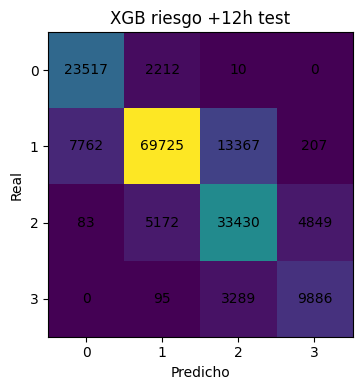

Modelo guardado: /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/xgboost_risk/xgb_risk_12h.pkl
Entrenando XGBClassifier horizonte +24h
Target: target_risk_24h
Train: (696348, 109) {0: 122203, 1: 370186, 2: 164047, 3: 39912}
Val: (87120, 109) {0: 14839, 1: 44583, 2: 23498, 3: 4200}
Test: (173376, 109) {0: 25712, 1: 90914, 2: 43489, 3: 13261}
Class weights: {0: 1.4245722281777042, 1: 0.4702689999081543, 2: 1.3265024657567648, 3: 7.633099067949488}
[0]	validation_0-mlogloss:1.49490
[100]	validation_0-mlogloss:0.90076
[200]	validation_0-mlogloss:0.84157
[300]	validation_0-mlogloss:0.81763
[400]	validation_0-mlogloss:0.80372
[500]	validation_0-mlogloss:0.79095
[600]	validation_0-mlogloss:0.78313
[700]	validation_0-mlogloss:0.77482
[800]	validation_0-mlogloss:0.76928
[899]	validation_0-mlogloss:0.76394


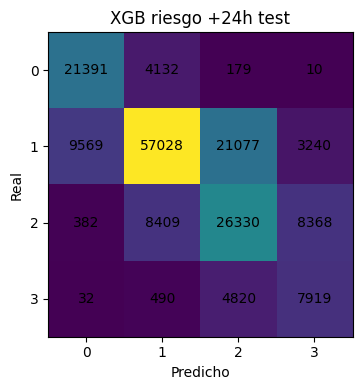

Modelo guardado: /content/drive/MyDrive/AI Projects/DeepWave Canarias/models/xgboost_risk/xgb_risk_24h.pkl
Modelos XGBoost entrenados: 4


In [11]:
training_results = []

for h in HORIZONS_HOURS:
    result = train_xgb_for_horizon(h)
    training_results.append(result)

print("Modelos XGBoost entrenados:", len(training_results))

## Celda 10 — Consolidar métricas y resultados

In [12]:
metrics_all = pd.concat([r["metrics"] for r in training_results], ignore_index=True)
predictions_all = pd.concat([r["predictions"] for r in training_results], ignore_index=True)
feature_importance_all = pd.concat([r["importance"] for r in training_results], ignore_index=True)
classification_report_all = pd.concat([r["report_test"] for r in training_results], ignore_index=True)

metrics_all.to_csv(RESULTS_DIR / "metrics_risk.csv", index=False)
feature_importance_all.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)
classification_report_all.to_csv(RESULTS_DIR / "classification_report_test_xgb.csv", index=False)

predictions_all.to_parquet(RESULTS_DIR / "val_test_predictions.parquet", index=False, engine="pyarrow", compression="snappy")

display(metrics_all)
display(feature_importance_all.head(40))
display(classification_report_all)
display(predictions_all.head())
print("Resultados guardados en:", RESULTS_DIR)

,horizon_hours,target,split,model,log_loss,fit_mode,n,accuracy,balanced_accuracy,macro_f1,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,train,XGBClassifier,0.100825,early_stopping_in_params,698181,0.960106,0.973817,0.959781,...,0.965601,371292,0.927367,0.960650,0.943715,164473,0.935718,0.997373,0.965562,39975
1,3,target_risk_3h,train,PersistenceRisk,NaN,baseline,698181,0.929232,0.917831,0.917855,...,0.945091,371292,0.894900,0.894536,0.894718,164473,0.891916,0.891982,0.891949,39975
2,3,target_risk_3h,val,XGBClassifier,0.150396,early_stopping_in_params,87300,0.939141,0.947239,0.929302,...,0.949141,44724,0.913819,0.940514,0.926974,23518,0.859182,0.945489,0.900272,4201
3,3,target_risk_3h,val,PersistenceRisk,NaN,baseline,87300,0.923219,0.909474,0.909533,...,0.937376,44724,0.902034,0.901267,0.901651,23518,0.869079,0.869079,0.869079,4201
4,3,target_risk_3h,test,XGBClassifier,0.158671,early_stopping_in_params,174135,0.934775,0.946344,0.930576,...,0.946876,91327,0.896956,0.932694,0.914476,43696,0.903854,0.958092,0.930183,13315
5,3,target_risk_3h,test,PersistenceRisk,NaN,baseline,174135,0.918489,0.909337,0.909224,...,0.937561,91327,0.885610,0.886077,0.885843,43696,0.894547,0.895757,0.895152,13315
6,6,target_risk_6h,train,XGBClassifier,0.191838,early_stopping_in_params,697650,0.923886,0.948032,0.921549,...,0.934814,371009,0.866316,0.916871,0.890877,164335,0.865193,0.989984,0.923391,39935
7,6,target_risk_6h,train,PersistenceRisk,NaN,baseline,697650,0.875405,0.853892,0.853924,...,0.903959,371009,0.813730,0.813047,0.813388,164335,0.802363,0.802604,0.802484,39935
8,6,target_risk_6h,val,XGBClassifier,0.279458,early_stopping_in_params,87240,0.882393,0.894053,0.864417,...,0.900625,44665,0.835032,0.877450,0.855716,23525,0.742461,0.879076,0.805014,4201
9,6,target_risk_6h,val,PersistenceRisk,NaN,baseline,87240,0.865463,0.840270,0.840385,...,0.890808,44665,0.827220,0.825462,0.826340,23525,0.764818,0.764818,0.764818,4201


,feature,importance_gain,importance_weight,horizon_hours
0,simar_hs,1552.345947,14540.0,3
1,simar_hs_lag_1h,347.853729,7173.0,3
2,simar_hs_roll_mean_6h,214.116058,1863.0,3
3,simar_hs_lag_3h,181.558578,4075.0,3
4,simar_hs_lag_6h,47.461109,2394.0,3
5,simar_tp,25.313070,1889.0,3
6,simar_wind_speed,24.764158,4085.0,3
7,simar_hs_roll_max_12h,22.015484,2026.0,3
8,simar_wind_speed_roll_max_12h,20.735924,3163.0,3
9,zona_lat,20.454475,1194.0,3


,class,precision,recall,f1-score,support,horizon_hours
0,0,0.892036,0.973020,0.930770,25797.000000,3
1,1,0.973613,0.921568,0.946876,91327.000000,3
2,2,0.896956,0.932694,0.914476,43696.000000,3
3,3,0.903854,0.958092,0.930183,13315.000000,3
4,accuracy,0.934775,0.934775,0.934775,0.934775,3
5,macro avg,0.916615,0.946344,0.930576,174135.000000,3
6,weighted avg,0.936958,0.934775,0.935083,174135.000000,3
7,0,0.823482,0.954420,0.884130,25779.000000,6
8,1,0.949936,0.858217,0.901750,91245.000000,6
9,2,0.807403,0.870294,0.837669,43637.000000,6


,zona_id,timestamp,split,isla,lat,lon,simar_hs,target_risk_3h,horizon_hours,y_true_risk,pred_risk_xgb,pred_risk_persistence,proba_risk_0,proba_risk_1,proba_risk_2,proba_risk_3,target_risk_6h,target_risk_12h,target_risk_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.50,0,3,0,0,0,0.980942,0.018985,0.000062,0.000010,<NA>,<NA>,<NA>
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.45,0,3,0,0,0,0.987905,0.012035,0.000048,0.000011,<NA>,<NA>,<NA>
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.43,1,3,1,0,0,0.976630,0.023288,0.000067,0.000014,<NA>,<NA>,<NA>
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.52,1,3,1,0,0,0.960945,0.038918,0.000102,0.000035,<NA>,<NA>,<NA>
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.79,1,3,1,1,0,0.459806,0.539881,0.000238,0.000075,<NA>,<NA>,<NA>


Resultados guardados en: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk


## Celda 11 — Comparativa principal en test

In [13]:
test_metrics = metrics_all[metrics_all["split"] == "test"].copy()
display(test_metrics)

test_pivot = test_metrics.pivot_table(
    index=["horizon_hours", "target"],
    columns="model",
    values=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "recall_class_2", "recall_class_3", "f1_class_2", "f1_class_3"],
)
display(test_pivot)

improvement_rows = []
for h in HORIZONS_HOURS:
    subset = test_metrics[test_metrics["horizon_hours"] == h]
    xgb_row = subset[subset["model"] == "XGBClassifier"].iloc[0]
    base_row = subset[subset["model"] == "PersistenceRisk"].iloc[0]
    improvement_rows.append({
        "horizon_hours": h,
        "accuracy_persistence": base_row["accuracy"],
        "accuracy_xgb": xgb_row["accuracy"],
        "accuracy_improvement_pct_points": float((xgb_row["accuracy"] - base_row["accuracy"]) * 100),
        "balanced_accuracy_persistence": base_row["balanced_accuracy"],
        "balanced_accuracy_xgb": xgb_row["balanced_accuracy"],
        "balanced_accuracy_improvement_pct_points": float((xgb_row["balanced_accuracy"] - base_row["balanced_accuracy"]) * 100),
        "macro_f1_persistence": base_row["macro_f1"],
        "macro_f1_xgb": xgb_row["macro_f1"],
        "macro_f1_improvement_pct_points": float((xgb_row["macro_f1"] - base_row["macro_f1"]) * 100),
        "recall_class_2_persistence": base_row["recall_class_2"],
        "recall_class_2_xgb": xgb_row["recall_class_2"],
        "recall_class_3_persistence": base_row["recall_class_3"],
        "recall_class_3_xgb": xgb_row["recall_class_3"],
    })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)
improvement_df.to_csv(RESULTS_DIR / "test_improvement_vs_persistence.csv", index=False)

,horizon_hours,target,split,model,log_loss,fit_mode,n,accuracy,balanced_accuracy,macro_f1,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
4,3,target_risk_3h,test,XGBClassifier,0.158671,early_stopping_in_params,174135,0.934775,0.946344,0.930576,...,0.946876,91327,0.896956,0.932694,0.914476,43696,0.903854,0.958092,0.930183,13315
5,3,target_risk_3h,test,PersistenceRisk,NaN,baseline,174135,0.918489,0.909337,0.909224,...,0.937561,91327,0.885610,0.886077,0.885843,43696,0.894547,0.895757,0.895152,13315
10,6,target_risk_6h,test,XGBClassifier,0.287189,early_stopping_in_params,173958,0.878315,0.894486,0.869121,...,0.901750,91245,0.807403,0.870294,0.837669,43637,0.814635,0.895014,0.852935,13297
11,6,target_risk_6h,test,PersistenceRisk,NaN,baseline,173958,0.858684,0.841002,0.840787,...,0.893297,91245,0.798755,0.799780,0.799267,43637,0.805970,0.808152,0.807060,13297
16,12,target_risk_12h,test,XGBClassifier,0.491617,early_stopping_in_params,173604,0.786606,0.798065,0.766844,...,0.828752,91061,0.667319,0.767906,0.714087,43534,0.661625,0.744989,0.700837,13270
17,12,target_risk_12h,test,PersistenceRisk,NaN,baseline,173604,0.773001,0.740646,0.740397,...,0.830814,91061,0.673303,0.675036,0.674168,43534,0.663017,0.666164,0.664587,13270
22,24,target_risk_24h,test,XGBClassifier,0.760339,early_stopping_in_params,173376,0.649848,0.665456,0.622502,...,0.708541,90914,0.502423,0.605440,0.549142,43489,0.405333,0.597165,0.482895,13261
23,24,target_risk_24h,test,PersistenceRisk,NaN,baseline,173376,0.666546,0.614597,0.614795,...,0.750444,90914,0.523010,0.524753,0.523880,43489,0.473185,0.473720,0.473452,13261


accuracy               balanced_accuracy  \
model                         PersistenceRisk XGBClassifier   PersistenceRisk   
horizon_hours target                                                            
3             target_risk_3h         0.918489      0.934775          0.909337   
6             target_risk_6h         0.858684      0.878315          0.841002   
12            target_risk_12h        0.773001      0.786606          0.740646   
24            target_risk_24h        0.666546      0.649848          0.614597   

                                                 f1_class_2                \
model                         XGBClassifier PersistenceRisk XGBClassifier   
horizon_hours target                                                        
3             target_risk_3h       0.946344        0.885843      0.914476   
6             target_risk_6h       0.894486        0.799267      0.837669   
12            target_risk_12h      0.798065        0.674168      0.714087   
24            target_risk_24h      0.665456        0.523880      0.549142   

                                   f1_class_3                      macro_f1  \
model                         PersistenceRisk XGBClassifier PersistenceRisk   
horizon_hours target                                                          
3             target_risk_3h         0.895152      0.930183        0.909224   
6             target_risk_6h         0.807060      0.852935        0.840787   
12            target_risk_12h        0.664587      0.700837        0.740397   
24            target_risk_24h        0.473452      0.482895        0.614795   

                                             recall_class_2                \
model                         XGBClassifier PersistenceRisk XGBClassifier   
horizon_hours target                                                        
3             target_risk_3h       0.930576        0.886077      0.932694   
6             target_risk_6h       0.869121        0.799780      0.870294   
12            target_risk_12h      0.766844        0.675036      0.767906   
24            target_risk_24h      0.622502        0.524753      0.605440   

                               recall_class_3                   weighted_f1  \
model                         PersistenceRisk XGBClassifier PersistenceRisk   
horizon_hours target                                                          
3             target_risk_3h         0.895757      0.958092        0.918493   
6             target_risk_6h         0.808152      0.895014        0.858706   
12            target_risk_12h        0.666164      0.744989        0.773075   
24            target_risk_24h        0.473720      0.597165        0.666638   

                                             
model                         XGBClassifier  
horizon_hours target                         
3             target_risk_3h       0.935083  
6             target_risk_6h       0.879333  
12            target_risk_12h      0.789471  
24            target_risk_24h      0.657363

,horizon_hours,accuracy_persistence,accuracy_xgb,accuracy_improvement_pct_points,balanced_accuracy_persistence,balanced_accuracy_xgb,balanced_accuracy_improvement_pct_points,macro_f1_persistence,macro_f1_xgb,macro_f1_improvement_pct_points,recall_class_2_persistence,recall_class_2_xgb,recall_class_3_persistence,recall_class_3_xgb
0,3,0.918489,0.934775,1.628621,0.909337,0.946344,3.700675,0.909224,0.930576,2.135209,0.886077,0.932694,0.895757,0.958092
1,6,0.858684,0.878315,1.963118,0.841002,0.894486,5.348432,0.840787,0.869121,2.833389,0.799780,0.870294,0.808152,0.895014
2,12,0.773001,0.786606,1.360568,0.740646,0.798065,5.741923,0.740397,0.766844,2.644672,0.675036,0.767906,0.666164,0.744989
3,24,0.666546,0.649848,-1.669781,0.614597,0.665456,5.085918,0.614795,0.622502,0.770749,0.524753,0.605440,0.473720,0.597165


## Celda 12 — Gráficos de métricas de riesgo

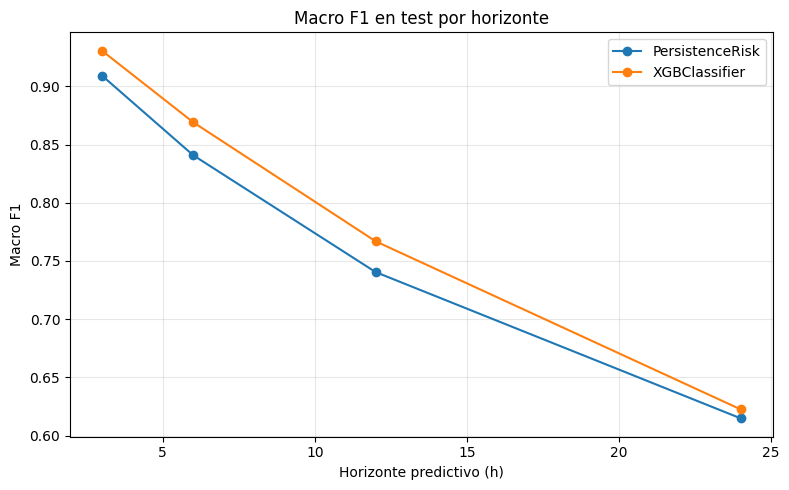

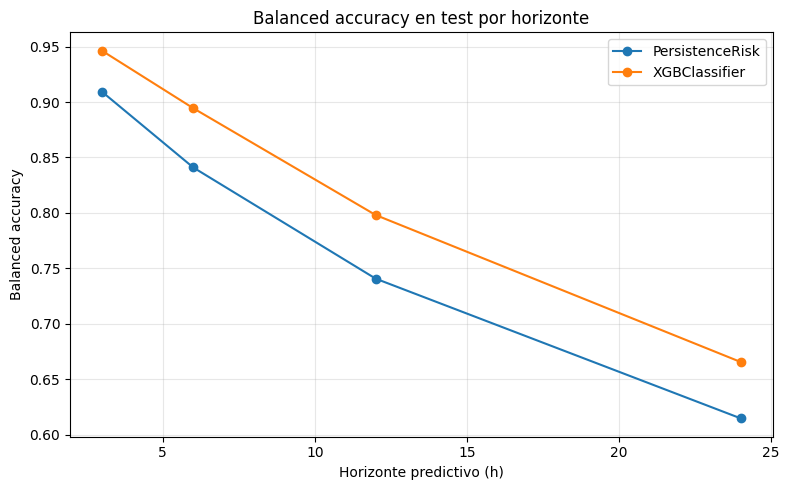

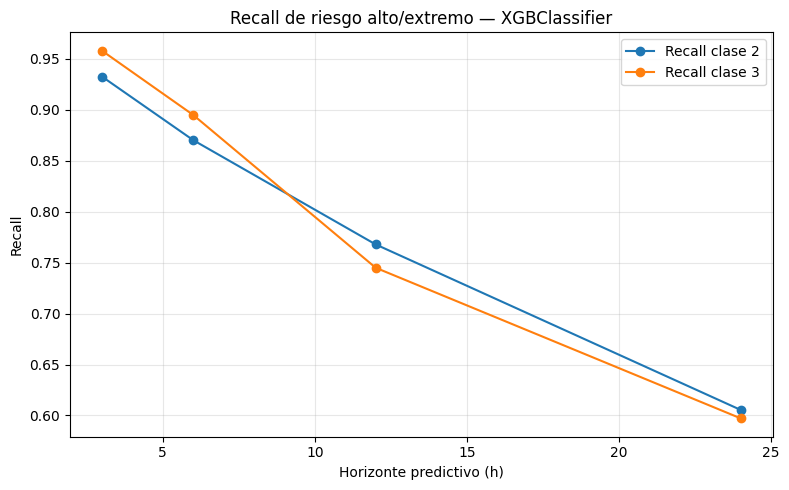

In [14]:
plt.figure(figsize=(8, 5))
for model_name in ["PersistenceRisk", "XGBClassifier"]:
    data = test_metrics[test_metrics["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["macro_f1"], marker="o", label=model_name)
plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("Macro F1")
plt.title("Macro F1 en test por horizonte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_macro_f1_by_horizon.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
for model_name in ["PersistenceRisk", "XGBClassifier"]:
    data = test_metrics[test_metrics["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["balanced_accuracy"], marker="o", label=model_name)
plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("Balanced accuracy")
plt.title("Balanced accuracy en test por horizonte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_balanced_accuracy_by_horizon.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
data = test_metrics[test_metrics["model"] == "XGBClassifier"].sort_values("horizon_hours")
for cls in [2, 3]:
    plt.plot(data["horizon_hours"], data[f"recall_class_{cls}"], marker="o", label=f"Recall clase {cls}")
plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("Recall")
plt.title("Recall de riesgo alto/extremo — XGBClassifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_recall_classes_2_3.png", dpi=150)
plt.show()

## Celda 13 — Importancia de variables

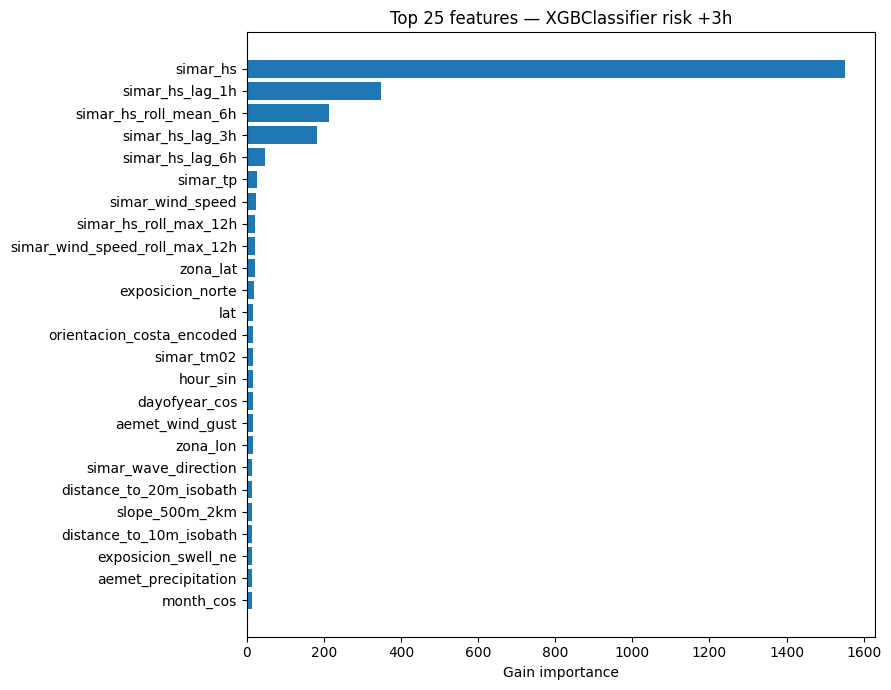

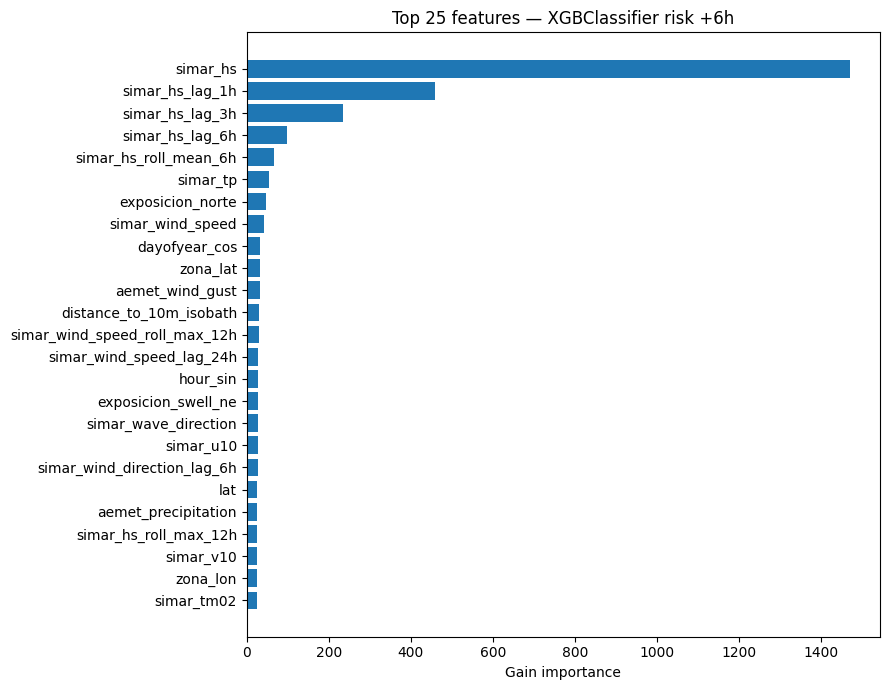

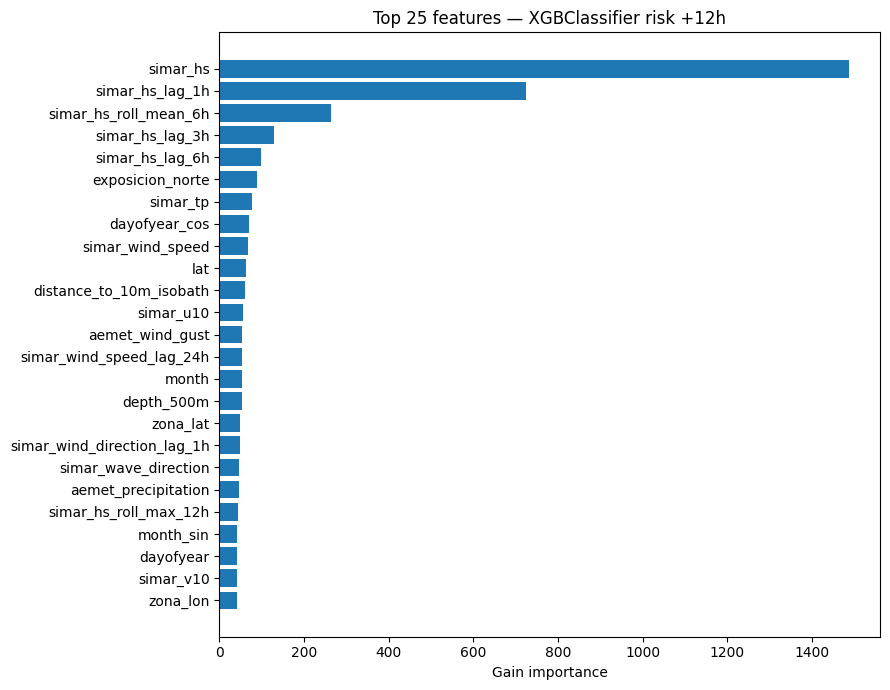

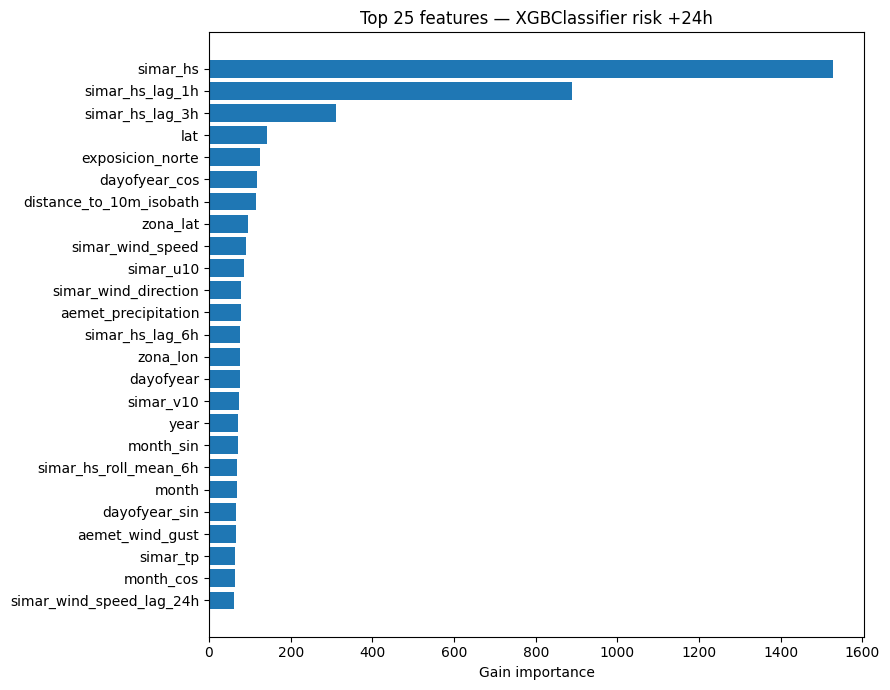

In [15]:
for h in HORIZONS_HOURS:
    imp = feature_importance_all[feature_importance_all["horizon_hours"] == h].sort_values("importance_gain", ascending=False).head(25)
    plt.figure(figsize=(9, 7))
    plt.barh(imp["feature"][::-1], imp["importance_gain"][::-1])
    plt.xlabel("Gain importance")
    plt.title(f"Top 25 features — XGBClassifier risk +{h}h")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"plot_feature_importance_h{h}.png", dpi=150)
    plt.show()

## Celda 14 — Guardar configuración de entrenamiento

In [16]:
training_config = {
    "model_family": "XGBClassifier",
    "task": "direct_risk_classification",
    "target_source": "SIMAR",
    "horizons_hours": HORIZONS_HOURS,
    "use_common_zones_only": USE_COMMON_ZONES_ONLY,
    "common_zones_count": len(common_zones),
    "common_zones": sorted(list(common_zones)),
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
    "feature_cols_raw": feature_cols,
    "feature_cols_encoded": feature_cols_encoded,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "category_maps": category_maps,
    "class_safety_boost": CLASS_SAFETY_BOOST,
    "max_train_rows_per_horizon": MAX_TRAIN_ROWS_PER_HORIZON,
    "random_state": RANDOM_STATE,
    "models": {f"risk_{r['horizon']}h": r["model_path"] for r in training_results},
    "class_weights_by_horizon": {f"risk_{r['horizon']}h": r["class_weights"] for r in training_results},
    "fit_mode_by_horizon": {f"risk_{r['horizon']}h": r["fit_mode"] for r in training_results},
}

save_json(training_config, RESULTS_DIR / "training_config.json")
save_json(training_config, MODELS_DIR / "training_config.json")
print("Configuración guardada.")
print(RESULTS_DIR / "training_config.json")
print(MODELS_DIR / "training_config.json")

Configuración guardada.
/content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/training_config.json
/content/drive/MyDrive/AI Projects/DeepWave Canarias/models/xgboost_risk/training_config.json


## Celda 15 — Validación final

In [18]:
required_files = [
    RESULTS_DIR / "metrics_risk.csv",
    RESULTS_DIR / "feature_importance.csv",
    RESULTS_DIR / "classification_report_test_xgb.csv",
    RESULTS_DIR / "val_test_predictions.parquet",
    RESULTS_DIR / "test_improvement_vs_persistence.csv",
    RESULTS_DIR / "training_config.json",
    RESULTS_DIR / "category_maps.json",
]
for h in HORIZONS_HOURS:
    required_files.append(MODELS_DIR / f"xgb_risk_{h}h.pkl")

missing_files = [str(p) for p in required_files if not Path(p).exists()]
if missing_files:
    raise FileNotFoundError("Faltan archivos de salida: " + json.dumps(missing_files, indent=2))

test_xgb = metrics_all[(metrics_all["split"] == "test") & (metrics_all["model"] == "XGBClassifier")]
if test_xgb["horizon_hours"].nunique() != len(HORIZONS_HOURS):
    raise ValueError("No hay métricas test XGBClassifier para todos los horizontes.")
if test_xgb["macro_f1"].isna().any() or test_xgb["balanced_accuracy"].isna().any():
    raise ValueError("Hay métricas macro_f1/balanced_accuracy nulas en test.")

print("Archivos generados:")
for p in sorted(RESULTS_DIR.glob("*")):
    print("-", p)

print("\nModelos generados:")
for p in sorted(MODELS_DIR.glob("*.pkl")):
    print("-", p)

print("\nResumen test XGBClassifier:")
display(test_xgb[["horizon_hours", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "recall_class_2", "recall_class_3", "f1_class_2", "f1_class_3"]])

print("\n✅ Entrenamiento XGBClassifier de riesgo completado correctamente.")

Archivos generados:
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/category_maps.json
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/classification_report_test_xgb.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/classification_report_test_xgb_h12.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/classification_report_test_xgb_h24.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/classification_report_test_xgb_h3.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/classification_report_test_xgb_h6.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/confusion_matrix_persistence_h12_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk/confusion_matrix_persistence_h12_t

,horizon_hours,accuracy,balanced_accuracy,macro_f1,weighted_f1,recall_class_2,recall_class_3,f1_class_2,f1_class_3
4,3,0.934775,0.946344,0.930576,0.935083,0.932694,0.958092,0.914476,0.930183
10,6,0.878315,0.894486,0.869121,0.879333,0.870294,0.895014,0.837669,0.852935
16,12,0.786606,0.798065,0.766844,0.789471,0.767906,0.744989,0.714087,0.700837
22,24,0.649848,0.665456,0.622502,0.657363,0.605440,0.597165,0.549142,0.482895



✅ Entrenamiento XGBClassifier de riesgo completado correctamente.


## Resultado esperado

Al terminar debe aparecer:

```text
✅ Entrenamiento XGBClassifier de riesgo completado correctamente.
```

Archivos principales:

```text
models/xgboost_risk/xgb_risk_3h.pkl
models/xgboost_risk/xgb_risk_6h.pkl
models/xgboost_risk/xgb_risk_12h.pkl
models/xgboost_risk/xgb_risk_24h.pkl

gold/model_results/xgboost_risk/metrics_risk.csv
gold/model_results/xgboost_risk/feature_importance.csv
gold/model_results/xgboost_risk/classification_report_test_xgb.csv
gold/model_results/xgboost_risk/val_test_predictions.parquet
gold/model_results/xgboost_risk/test_improvement_vs_persistence.csv
```

Este modelo debe compararse después contra el riesgo derivado desde LightGBMRegressor.